In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import Callback
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import cv2

In [2]:
# custom functions
from src.models import resnet_ssd_min
from src.nn_tools import find_overfitting_piont
from src import tf_custom_callbacks

In [3]:
import importlib
def reload_imports():
    importlib.reload(resnet_ssd_min)
    importlib.reload(tf_custom_callbacks)

reload_imports()

In [4]:
# global variables
from config import GLOBAL_CONFIG_RESULT_PATH, GLOBAL_CONFIG_DATA_PATH, GLOBAL_CONFIG_DATA_RAW_IMAGE_PATH, GLOBAL_CONFIG_DATA_RAW_LABEL_PATH

In [5]:
# padding image on the right side and top side
def pad_image(img, target_shape):
    img_shape = img.shape
    # Calculate padding for each dimension
    pad_height = target_shape[0] - img_shape[0]
    pad_width = target_shape[1] - img_shape[1]
    # Construct the padding for each axis
    pad_shape = ((0, pad_height), (0, pad_width), (0, 0))  # (top, bottom), (left, right), (channels)
    
    return np.pad(img, pad_shape, mode='constant', constant_values=0)

# resize image to target shape
def resize_image(img, target_shape):
    return cv2.resize(img, target_shape, interpolation=cv2.INTER_NEAREST)

In [6]:
reload_imports()

# define the model
model = resnet_ssd_min.small_resnet_ssd(input_shape=(255, 255, 3), num_classes=2, num_boxes=100)

model.summary()

Model: "small_resnet_ssd"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 255, 255,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ initial_conv        │ (None, 128, 128,  │      2,368 │ input_layer[0][0] │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ initial_bn          │ (None, 128, 128,  │         64 │ initial_conv[0][… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ initial_relu (ReLU) │ (None, 128, 128,  │          0 │ initial_bn[0][0]  │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ initial_pool        │ (None, 64, 64,    │          0 │ initial_relu[0][… │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_block1_conv1   │ (None, 64, 64,    │      2,320 │ initial_pool[0][… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_block1_bn1     │ (None, 64, 64,    │         64 │ conv_block1_conv… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_block1_relu1   │ (None, 64, 64,    │          0 │ conv_block1_bn1[… │
│ (ReLU)              │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_block1_conv2   │ (None, 64, 64,    │      2,320 │ conv_block1_relu… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_block1_bn2     │ (None, 64, 64,    │         64 │ conv_block1_conv… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_block1_add     │ (None, 64, 64,    │          0 │ conv_block1_bn2[… │
│ (Add)               │ 16)               │            │ initial_pool[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_block1_out     │ (None, 64, 64,    │          0 │ conv_block1_add[… │
│ (ReLU)              │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ identity_block1_co… │ (None, 64, 64,    │      2,320 │ conv_block1_out[… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ identity_block1_bn1 │ (None, 64, 64,    │         64 │ identity_block1_… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ identity_block1_re… │ (None, 64, 64,    │          0 │ identity_block1_… │
│ (ReLU)              │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ identity_block1_co… │ (None, 64, 64,    │      2,320 │ identity_block1_… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ identity_block1_bn2 │ (None, 64, 64,    │         64 │ identity_block1_

 Total params: 317,432 (1.21 MB)

 Trainable params: 315,928 (1.21 MB)

 Non-trainable params: 1,504 (5.88 KB)

In [7]:
# load label data
df_label = pd.read_csv(GLOBAL_CONFIG_DATA_RAW_LABEL_PATH)

# 1 image id multiple bounding boxes
# get unique image id
df_label_unique = df_label[['Image_ID']].drop_duplicates()

df_label_unique.shape


(2747, 1)

In [8]:
# load image data
def load_image(image_id):
    img = cv2.imread(GLOBAL_CONFIG_DATA_RAW_IMAGE_PATH + "/" + image_id)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img

In [9]:
"""
# load images
images = []
max_hieght = 0
max_width = 0
num_unique_images = df_label_unique.shape[0]
for i in range(0, num_unique_images):
    img = load_image(df_label_unique.iloc[i]['Image_ID'])
    images.append(img)
    max_hieght = max(max_hieght, img.shape[0])
    max_width = max(max_width, img.shape[1])

# pad images to be square
images_padded = []
for img in images:
    img_padded = pad_image(img, (max_hieght, max_width))
    images_padded.append(img_padded)

# resize images to 255x255 and ajust bounding boxes
images_resized = []
for u_image_id, img in zip(df_label_unique['Image_ID'], images_padded):
    original_shape = img.shape
    img_resized = resize_image(img, (255, 255))
    images_resized.append(img_resized)

    # ajust bounding boxes
    df_label_image = df_label[df_label['Image_ID'] == u_image_id]

    for i in range(0, df_label_image.shape[0]):
        # get bounding box
        axmin, aymin, axmax, aymax = df_label_image.iloc[i][['xmin', 'ymin', 'xmax', 'ymax']]

        # bounding box in original image to percentage
        xmin = axmin / original_shape[1]
        xmax = axmax / original_shape[1]
        ymin = aymin / original_shape[0]
        ymax = aymax / original_shape[0]

        # bounding box in resized image
        xmin = xmin * 255
        xmax = xmax * 255
        ymin = ymin * 255
        ymax = ymax * 255

        # update bounding box
        df_label.loc[(df_label['Image_ID'] == u_image_id) & (df_label['xmin'] == axmin), 'xmin'] = xmin
        df_label.loc[(df_label['Image_ID'] == u_image_id) & (df_label['xmax'] == axmax), 'xmax'] = xmax
        df_label.loc[(df_label['Image_ID'] == u_image_id) & (df_label['ymin'] == aymin), 'ymin'] = ymin
        df_label.loc[(df_label['Image_ID'] == u_image_id) & (df_label['ymax'] == aymax), 'ymax'] = ymax

# shape of resized images
# number of images, height, width, channels
print("number of images: ", len(images))
print(np.array(images_padded).shape)
print(np.array(images_resized).shape)
"""

'\n# load images\nimages = []\nmax_hieght = 0\nmax_width = 0\nnum_unique_images = df_label_unique.shape[0]\nfor i in range(0, num_unique_images):\n    img = load_image(df_label_unique.iloc[i][\'Image_ID\'])\n    images.append(img)\n    max_hieght = max(max_hieght, img.shape[0])\n    max_width = max(max_width, img.shape[1])\n\n# pad images to be square\nimages_padded = []\nfor img in images:\n    img_padded = pad_image(img, (max_hieght, max_width))\n    images_padded.append(img_padded)\n\n# resize images to 255x255 and ajust bounding boxes\nimages_resized = []\nfor u_image_id, img in zip(df_label_unique[\'Image_ID\'], images_padded):\n    original_shape = img.shape\n    img_resized = resize_image(img, (255, 255))\n    images_resized.append(img_resized)\n\n    # ajust bounding boxes\n    df_label_image = df_label[df_label[\'Image_ID\'] == u_image_id]\n\n    for i in range(0, df_label_image.shape[0]):\n        # get bounding box\n        axmin, aymin, axmax, aymax = df_label_image.iloc[i]

In [9]:
# load images, process and ajust bounding boxes and save to disk
save_path = GLOBAL_CONFIG_DATA_PATH + "/processed_images_damian/"
csv_save_path = GLOBAL_CONFIG_DATA_PATH + "/processed_images_damian.csv"

In [ ]:


# create directory
import os
if not os.path.exists(save_path):
    os.makedirs(save_path)

max_hieght = 0
max_width = 0
num_unique_images = df_label_unique.shape[0]
for i in range(0, num_unique_images):
    img = load_image(df_label_unique.iloc[i]['Image_ID'])
    # images.append(img)
    max_hieght = max(max_hieght, img.shape[0])
    max_width = max(max_width, img.shape[1])

    max_dim = max(img.shape[0], img.shape[1])

    # pad images to be square
    img_padded = pad_image(img, (max_dim, max_dim))
    # images_padded.append(img_padded)

    u_image_id = df_label_unique.iloc[i]['Image_ID']
    original_shape = img_padded.shape
    img_resized = resize_image(img_padded, (255, 255))
    # images_resized.append(img_resized)

    # save image
    cv2.imwrite(save_path + u_image_id, cv2.cvtColor(img_resized, cv2.COLOR_RGB2BGR))

    # ajust bounding boxes
    df_label_image = df_label[df_label['Image_ID'] == u_image_id]

    for i in range(0, df_label_image.shape[0]):
        # get bounding box
        axmin, aymin, axmax, aymax = df_label_image.iloc[i][['xmin', 'ymin', 'xmax', 'ymax']]

        # bounding box in original image to percentage
        xmin = axmin / original_shape[1]
        xmax = axmax / original_shape[1]
        ymin = aymin / original_shape[0]
        ymax = aymax / original_shape[0]

        # bounding box in resized image
        xmin = xmin * 255
        xmax = xmax * 255
        ymin = ymin * 255
        ymax = ymax * 255

        # update bounding box
        df_label.loc[(df_label['Image_ID'] == u_image_id) & (df_label['xmin'] == axmin), 'xmin'] = xmin
        df_label.loc[(df_label['Image_ID'] == u_image_id) & (df_label['xmax'] == axmax), 'xmax'] = xmax
        df_label.loc[(df_label['Image_ID'] == u_image_id) & (df_label['ymin'] == aymin), 'ymin'] = ymin
        df_label.loc[(df_label['Image_ID'] == u_image_id) & (df_label['ymax'] == aymax), 'ymax'] = ymax

# save processed labels
df_label.to_csv(csv_save_path, index=False)

C:\Users\djjor\AppData\Local\Temp\ipykernel_267084\1058129681.py:53: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '164.8203125' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_label.loc[(df_label['Image_ID'] == u_image_id) & (df_label['xmin'] == axmin), 'xmin'] = xmin
C:\Users\djjor\AppData\Local\Temp\ipykernel_267084\1058129681.py:54: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '168.671875' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_label.loc[(df_label['Image_ID'] == u_image_id) & (df_label['xmax'] == axmax), 'xmax'] = xmax
C:\Users\djjor\AppData\Local\Temp\ipykernel_267084\1058129681.py:55: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '94.5625' ha

In [10]:
# load processed images
images = []
num_unique_images = df_label_unique.shape[0]
for i in range(0, num_unique_images):
    img = cv2.imread(save_path + df_label_unique.iloc[i]['Image_ID'])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # normalize image
    img = img / 255.0

    images.append(img)

# load processed labels
df_label = pd.read_csv(csv_save_path)

# shape of resized images
# number of images, height, width, channels
print("number of images: ", len(images))
print(np.array(images).shape)

number of images:  2747
(2747, 255, 255, 3)


In [11]:
# Function to plot an image with its bounding boxes
def plot_image_with_boxes(image, boxes, YOLO_FORMAT=False, show_labels=True):
    # Get image dimensions
    h, w, _ = image.shape

    # Plot the image
    plt.figure(figsize=(10, 10))
    plt.imshow(image)

    # Plot each bounding box
    for box in boxes:
        if YOLO_FORMAT:
            class_id, x_center, y_center, width, height = box
            xmin = int((x_center - width / 2) * w)
            ymin = int((y_center - height / 2) * h)
            xmax = int((x_center + width / 2) * w)
            ymax = int((y_center + height / 2) * h)
        else:
            xmin, ymin, xmax, ymax, class_id = box

        # Draw the bounding box
        plt.gca().add_patch(plt.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                                          edgecolor='red', facecolor='none', linewidth=2))
        if show_labels:
            plt.text(xmin, ymin - 10, f'Class {int(class_id)}', color='red', fontsize=12, weight='bold')

    plt.axis('off')
    plt.show()

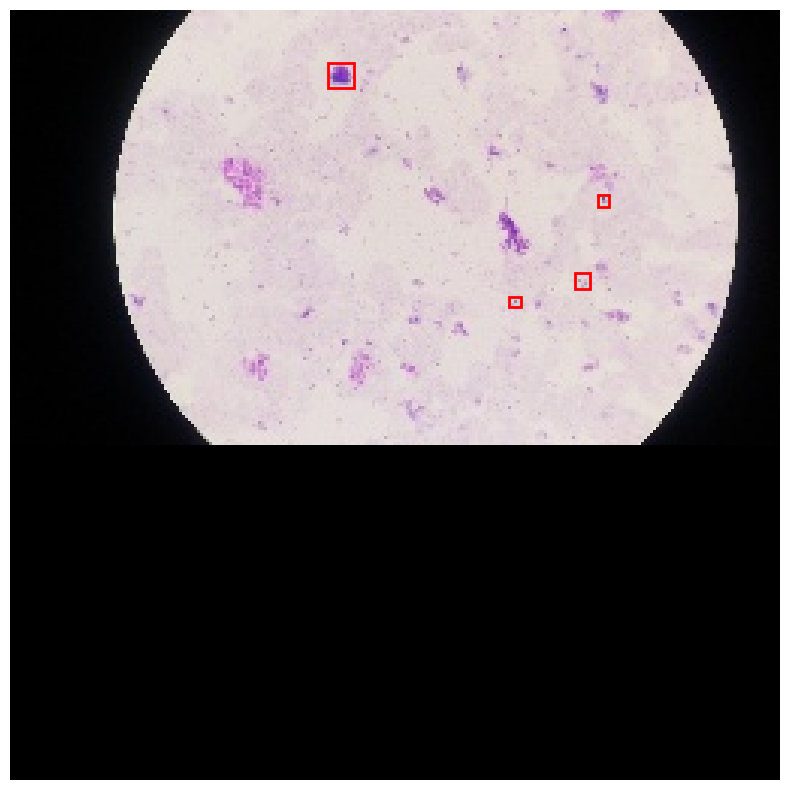

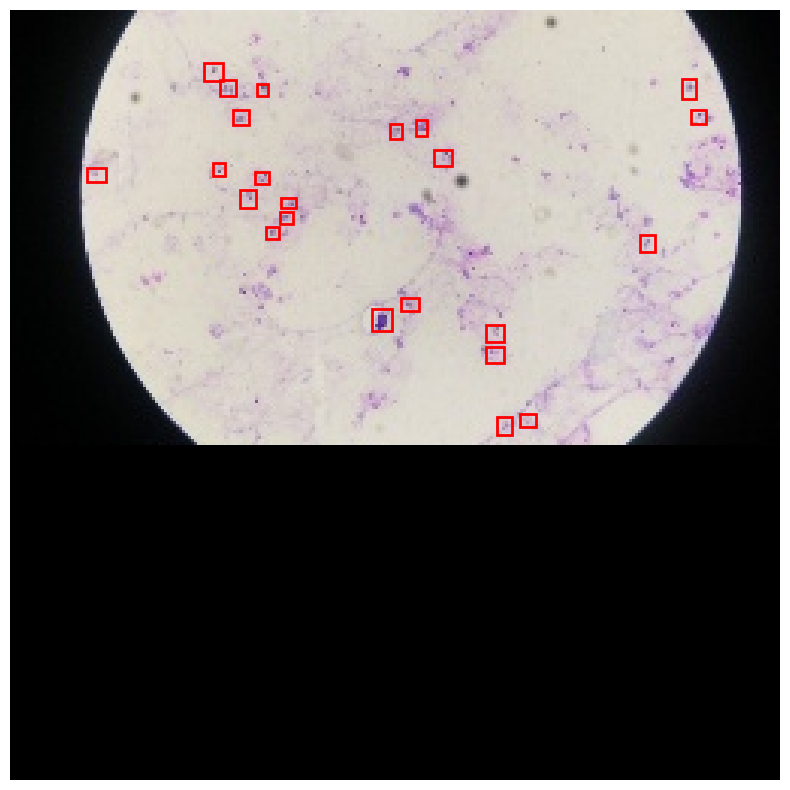

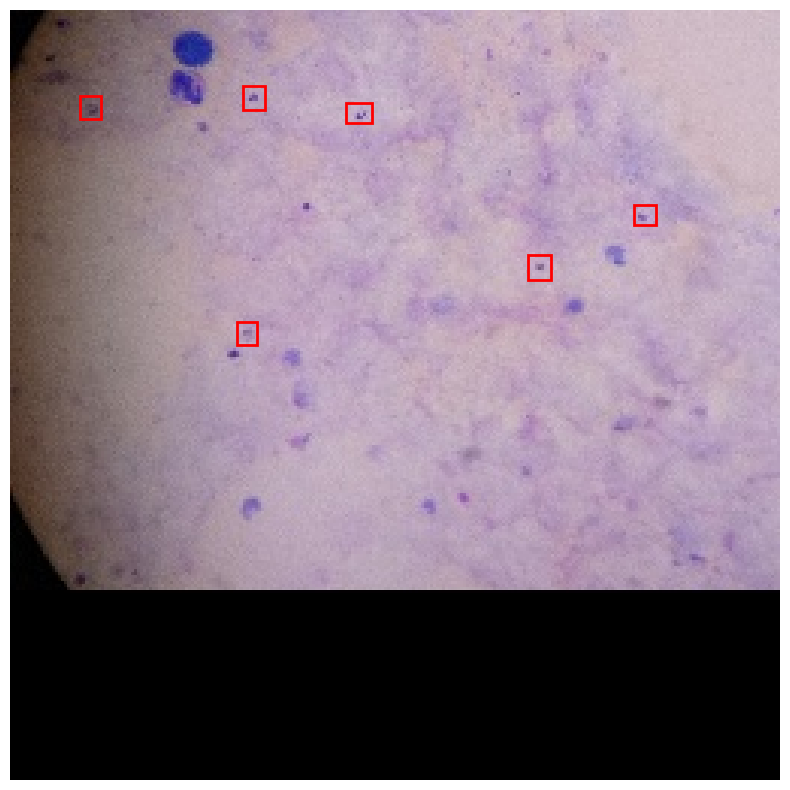

In [12]:
# plot image with bounding boxes to check if they are correct for the first 3 images
for i in range(0, 3):
    u_image_id = df_label_unique.iloc[i]['Image_ID']
    df_label_image = df_label[df_label['Image_ID'] == u_image_id]
    boxes = df_label_image[['xmin', 'ymin', 'xmax', 'ymax', 'class']].values
    plot_image_with_boxes(images[i], boxes, show_labels=False)

In [13]:
import numpy as np

def duplicate_items(arr, target_size):
    arr = np.array(arr)
    
    if target_size <= len(arr):
        return arr[:target_size]  # If target size is smaller, return a truncated array
    
    # Calculate the number of repeats for each item
    repeats = target_size // len(arr)
    remainder = target_size % len(arr)
    
    # Duplicate items equally
    result = np.tile(arr, (repeats, 1)) if arr.ndim == 2 else np.tile(arr, repeats)
    
    # Add the remaining items to match the target size
    remainder_items = arr[:remainder]
    if remainder_items.ndim == 1 and result.ndim == 2:
        remainder_items = remainder_items.reshape(-1, result.shape[1])
        
    result = np.concatenate((result, remainder_items))
    
    return result


In [14]:
# create dataset
# input: images_resized
# output: (bboxs, (xmin, ymin, xmax, ymax, class1, class2, ...))

target_y = []
target_x = []
removal_list = []
removal_list_index = []

# get max number of bounding boxes from max num instances of an image
max_num_boxes = df_label.groupby('Image_ID').size().max()

num_boxes = model.output_shape[1]
print(f"num_boxes: {num_boxes}")
num_classes = 2

for u_image_id in df_label_unique['Image_ID']:
    df_label_image = df_label[df_label['Image_ID'] == u_image_id]

    # get all bounding boxes for this image
    this_target_y = []
    for i in range(0, df_label_image.shape[0]):
        # if class is NEG
        if df_label_image.iloc[i]['class'] == 'NEG':
            continue

        bbox = df_label_image.iloc[i][['xmin', 'ymin', 'xmax', 'ymax']]
        # class_one_hot = pd.get_dummies(df_label_image.iloc[i]['class'])

        def pd_manually_one_hot_encode(class_name, classes):
            one_hot = np.zeros(len(classes))
            one_hot[classes.index(class_name)] = 1
            return one_hot
        
        class_one_hot = pd_manually_one_hot_encode(df_label_image.iloc[i]['class'], ['Trophozoite', 'WBC'])

        # add bounding box and class to target_y
        item = np.concatenate([bbox, class_one_hot])

        this_target_y.append(item)
        
        

    # if less than num_boxes, add zeros
    if len(this_target_y) < num_boxes:
        # for i in range(len(this_target_y), num_boxes):
        #     item = np.zeros(num_classes + 4)
        #     this_target_y.append(item)

        #     # equally duplicate all items in the list to fill the num_boxes
        #     # this_target_y = duplicate_items(this_target_y, num_boxes)

        new_this_target_y = []

        count = 0
        original_iter = 0

        print(f"for image: {u_image_id}")

        if len(this_target_y) == 0:
            # add to removal list
            removal_list.append(u_image_id)
            # index of u_image_id
            index = df_label_unique[df_label_unique['Image_ID'] == u_image_id].index[0]
            if index > df_label_unique.shape[0]:
                print(f"shit: {index}")
            removal_list_index.append(len(target_y))

        while count < num_boxes:
            if len(this_target_y) == 0:
                item = np.zeros(num_classes + 4)
                new_this_target_y.append(item)
                count += 1
            for i in range(0, len(this_target_y)):
                print(f"original_iter: {original_iter}, count: {count}")
                new_this_target_y.append(this_target_y[i])
                count += 1
                original_iter += 1
                if count >= num_boxes:
                    break
        
        this_target_y = new_this_target_y


    target_y.append(this_target_y)

print(f"removal_list: {len(removal_list)}")



num_boxes: 102
for image: id_u3q6jdck4j.jpg
original_iter: 0, count: 0
original_iter: 1, count: 1
original_iter: 2, count: 2
original_iter: 3, count: 3
original_iter: 4, count: 4
original_iter: 5, count: 5
original_iter: 6, count: 6
original_iter: 7, count: 7
original_iter: 8, count: 8
original_iter: 9, count: 9
original_iter: 10, count: 10
original_iter: 11, count: 11
original_iter: 12, count: 12
original_iter: 13, count: 13
original_iter: 14, count: 14
original_iter: 15, count: 15
original_iter: 16, count: 16
original_iter: 17, count: 17
original_iter: 18, count: 18
original_iter: 19, count: 19
original_iter: 20, count: 20
original_iter: 21, count: 21
original_iter: 22, count: 22
original_iter: 23, count: 23
original_iter: 24, count: 24
original_iter: 25, count: 25
original_iter: 26, count: 26
original_iter: 27, count: 27
original_iter: 28, count: 28
original_iter: 29, count: 29
original_iter: 30, count: 30
original_iter: 31, count: 31
original_iter: 32, count: 32
original_iter: 33, 

In [15]:
removal_list_index

[4,
 8,
 60,
 68,
 76,
 117,
 167,
 214,
 259,
 279,
 319,
 371,
 379,
 409,
 441,
 451,
 453,
 467,
 470,
 472,
 484,
 486,
 536,
 537,
 542,
 554,
 591,
 597,
 649,
 655,
 664,
 686,
 694,
 714,
 759,
 785,
 796,
 824,
 840,
 842,
 848,
 856,
 884,
 905,
 921,
 968,
 970,
 972,
 978,
 990,
 1026,
 1070,
 1079,
 1093,
 1105,
 1111,
 1145,
 1153,
 1154,
 1170,
 1172,
 1173,
 1185,
 1191,
 1222,
 1228,
 1238,
 1246,
 1256,
 1259,
 1285,
 1293,
 1302,
 1307,
 1311,
 1323,
 1338,
 1345,
 1347,
 1366,
 1371,
 1391,
 1394,
 1402,
 1403,
 1418,
 1425,
 1435,
 1439,
 1442,
 1451,
 1456,
 1457,
 1461,
 1465,
 1471,
 1473,
 1501,
 1508,
 1514,
 1515,
 1519,
 1527,
 1539,
 1544,
 1545,
 1546,
 1550,
 1554,
 1559,
 1562,
 1580,
 1588,
 1591,
 1599,
 1601,
 1602,
 1609,
 1612,
 1618,
 1624,
 1644,
 1646,
 1647,
 1649,
 1655,
 1656,
 1658,
 1663,
 1665,
 1670,
 1680,
 1684,
 1692,
 1693,
 1697,
 1730,
 1733,
 1736,
 1740,
 1742,
 1746,
 1752,
 1765,
 1766,
 1772,
 1773,
 1777,
 1780,
 1781,
 1787,


In [16]:
# remove images data from images and labels if they are in removal list
new_target_y = []
new_images = []
new_df_label_unique = df_label_unique[~df_label_unique['Image_ID'].isin(removal_list)]

for i in range(len(images)):
    if i not in removal_list_index:
        new_images.append(images[i])
        new_target_y.append(target_y[i])

images = new_images
df_label_unique = new_df_label_unique
target_y = new_target_y

In [17]:
# shape of target_y
# (num_images, num_boxes, 7)

# fix the shape of target_y
# target_y2 = []
# for i in range(0, len(target_y)):
#     if len(target_y[i]) < num_boxes:
#         for j in range(len(target_y[i]), num_boxes):
#             target_y[i].append(np.zeros(num_classes + 4))
#     for j in range(0, num_boxes):
#         if len(target_y[i][j]) < num_classes + 4:
#             target_y[i][j] = np.concatenate([target_y[i][j], np.zeros(num_classes + 4 - len(target_y[i][j]))])

# print odd shapes
for i in range(0, len(target_y)):
    if len(target_y[i]) != num_boxes:
        print(i, len(target_y[i]))
    for j in range(0, len(target_y[i])):
        if target_y[i][j].shape[0] != num_classes + 4:
            print(i, j, target_y[i][j].shape, "odd shape data:", target_y[i][j])

target_y2 = np.array(target_y)


target_y2.shape

(2059, 102, 6)

In [18]:
# print shapes X and Y
print("X shape:", np.array(images).shape)
print("Y shape:", target_y2.shape)

images_f32 = np.array(images).astype('float32')
target_y2_f32 = target_y2.astype('float32')

X shape: (2059, 255, 255, 3)
Y shape: (2059, 102, 6)


In [19]:
from tensorflow.keras.callbacks import Callback

# run model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# early stopping
patience = 600
min_delta = 0.0001
early_stopping_callback = tf_custom_callbacks.tf_early_stopping_2(patience=patience, min_delta=min_delta)

# train model
history = model.fit(images_f32, target_y2_f32, batch_size=8, epochs=600, validation_split=0.2, callbacks=[early_stopping_callback])

# save model
model.save(GLOBAL_CONFIG_RESULT_PATH + "/resnet_ssd_v1_min2.h5")


Epoch 1/600
206/206 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - accuracy: 0.6569 - loss: 3626.8699 - val_accuracy: 0.7370 - val_loss: 4660.1157
Epoch 2/600
206/206 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.7404 - loss: 4533.3394 - val_accuracy: 0.7370 - val_loss: 4659.5728
Epoch 3/600
206/206 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.7524 - loss: 4497.7412 - val_accuracy: 0.7370 - val_loss: 4308.9443
Epoch 4/600
206/206 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.7480 - loss: 3987.7178 - val_accuracy: 0.7370 - val_loss: 3384.4836
Epoch 5/600
206/206 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.7425 - loss: 3264.9871 - val_accuracy: 0.7370 - val_loss: 2869.0125
Epoch 6/600
206/206 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.7484 - loss: 2813.6223 - val_accuracy: 0.7370 - val_loss: 2860.6235
Epoch 7/600
206/206 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.7532 - loss: 2809.2981 - val_accuracy: 0.7370 - val_loss: 2914.5803
Epoch 8/600
206/206 ━━━━━━━━━━━━━━━━━━━━ 5s 23m

Restoring model weights from the end of the best epoch.
